# Fraud Detection - Model Training and Evaluation

Notebook structure:
1. Import libraries
2. Load data
3. Preprocess synthetic data (fraudTrain / fraudTest)
4. Preprocess real data (creditcard)
5. Train models on both datasets
6. Evaluate and compare results
7. Save the best models

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

print('Libraries imported.')

Libraries imported.


## 2. Load Data

We have 3 files:
- `fraudTrain.csv` - synthetic training data
- `fraudTest.csv` - synthetic test data
- `creditcard.csv` - real-world data (we do the train/test split manually)

In [3]:
print('Loading data...')

df_train_s = pd.read_csv('../data/fraudTrain.csv')
df_test_s  = pd.read_csv('../data/fraudTest.csv')
df_real    = pd.read_csv('../data/creditcard.csv')

print(f'fraudTrain.csv:  {df_train_s.shape[0]:,} rows, {df_train_s.shape[1]} columns')
print(f'fraudTest.csv:   {df_test_s.shape[0]:,} rows, {df_test_s.shape[1]} columns')
print(f'creditcard.csv:  {df_real.shape[0]:,} rows, {df_real.shape[1]} columns')

Loading data...
fraudTrain.csv:  1,296,675 rows, 23 columns
fraudTest.csv:   555,719 rows, 23 columns
creditcard.csv:  284,807 rows, 31 columns


In [9]:
df_train_s.head()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,category_food_dining,category_gas_transport,category_grocery_net,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,4.97,36.0788,-81.1781,3495,36.011293,-82.048315,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,45.00,46.2306,-112.1138,1939,47.034331,-112.561071,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,41.96,38.4207,-79.4629,99,38.674999,-78.632459,0,False,False,False,...,False,False,False,False,True,False,False,False,False,True


## 3. Preprocess Synthetic Data

The synthetic dataset has text columns that need to be encoded as numbers,
and numerical columns that need to be scaled.

In [5]:
# Drop personal info, ID columns, and cc_num (unique card identifier - no predictive value)
cols_to_drop = [
    'Unnamed: 0', 'trans_num', 'unix_time',
    'first', 'last', 'street', 'city', 'state',
    'zip', 'dob', 'trans_date_trans_time', 'merchant', 'job', 'cc_num'
]

# Only drop columns that actually exist in each file
df_train_s = df_train_s.drop(columns=[c for c in cols_to_drop if c in df_train_s.columns])
df_test_s  = df_test_s.drop(columns=[c for c in cols_to_drop if c in df_test_s.columns])

# Encode categorical columns (text to 0/1 dummy variables)
cat_cols = ['category', 'gender']
df_train_s = pd.get_dummies(df_train_s, columns=cat_cols, drop_first=True)
df_test_s  = pd.get_dummies(df_test_s,  columns=cat_cols, drop_first=True)

# Align columns - train and test must have exactly the same columns
# get_dummies can produce different columns if some values are missing in one set
df_train_s, df_test_s = df_train_s.align(df_test_s, join='left', axis=1, fill_value=0)

# Split features and target
X_train_s = df_train_s.drop(columns=['is_fraud'])
y_train_s = df_train_s['is_fraud']

X_test_s  = df_test_s.drop(columns=['is_fraud'])
y_test_s  = df_test_s['is_fraud']

# Scale numerical columns
# Important: fit only on train, then apply the same scaler to test
cols_to_scale = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']
cols_to_scale = [c for c in cols_to_scale if c in X_train_s.columns]

scaler_s = StandardScaler()
X_train_s[cols_to_scale] = scaler_s.fit_transform(X_train_s[cols_to_scale])
X_test_s[cols_to_scale]  = scaler_s.transform(X_test_s[cols_to_scale])

print('Synthetic data preprocessed.')
print(f'X_train_s: {X_train_s.shape}, fraud rate: {y_train_s.mean()*100:.2f}%')
print(f'X_test_s:  {X_test_s.shape},  fraud rate: {y_test_s.mean()*100:.2f}%')

Synthetic data preprocessed.
X_train_s: (1296675, 20), fraud rate: 0.58%
X_test_s:  (555719, 20),  fraud rate: 0.39%


## 4. Preprocess Real Data

The creditcard dataset already has PCA-transformed features (V1-V28),
so we only need to scale the Amount column and split the data.

In [13]:
# Drop Time (not useful) and separate features from target
X_real = df_real.drop(columns=['Class', 'Time'])
y_real = df_real['Class']

# 80/20 split, stratified to maintain the same fraud ratio in both sets
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

# Scale Amount - fit only on train
scaler_r = StandardScaler()
X_train_r[['Amount']] = scaler_r.fit_transform(X_train_r[['Amount']])
X_test_r[['Amount']]  = scaler_r.transform(X_test_r[['Amount']])

print('Real data preprocessed.')
print(f'X_train_r: {X_train_r.shape}, fraud rate: {y_train_r.mean()*100:.4f}%')
print(f'X_test_r:  {X_test_r.shape},  fraud rate: {y_test_r.mean()*100:.4f}%')

Real data preprocessed.
X_train_r: (227845, 29), fraud rate: 0.1729%
X_test_r:  (56962, 29),  fraud rate: 0.1720%


## 5. Evaluation Function

A single function that trains a model, makes predictions, and displays all metrics
along with the confusion matrix and ROC curve.

In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    """
    Trains and evaluates a model.
    Returns the trained model and its ROC-AUC score.
    """
    print(f'\n{model_name} | {dataset_name}')
    print('-' * 40)

    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of fraud (class 1)

    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

    roc_auc = roc_auc_score(y_test, y_proba)
    print(f'ROC-AUC: {roc_auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} - {dataset_name}', fontsize=13, fontweight='bold')

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Normal', 'Fraud'],
        cmap='Blues',
        ax=axes[0]
    )
    axes[0].set_title('Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (0.5)')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return model, roc_auc


# Compute class imbalance ratio - used to weight the minority class during training
fraud_ratio_s = int((y_train_s == 0).sum() / (y_train_s == 1).sum())
fraud_ratio_r = int((y_train_r == 0).sum() / (y_train_r == 1).sum())

print(f'Synthetic dataset: 1 fraud per {fraud_ratio_s} normal transactions')
print(f'Real dataset:      1 fraud per {fraud_ratio_r} normal transactions')

Synthetic dataset: 1 fraud per 171 normal transactions
Real dataset:      1 fraud per 577 normal transactions


## 6. Training on Synthetic Data

fraudTrain.csv is used for training, fraudTest.csv for evaluation.


Logistic Regression | Synthetic
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94    553574
       Fraud       0.03      0.74      0.05      2145

    accuracy                           0.89    555719
   macro avg       0.51      0.81      0.50    555719
weighted avg       1.00      0.89      0.94    555719

ROC-AUC: 0.9012


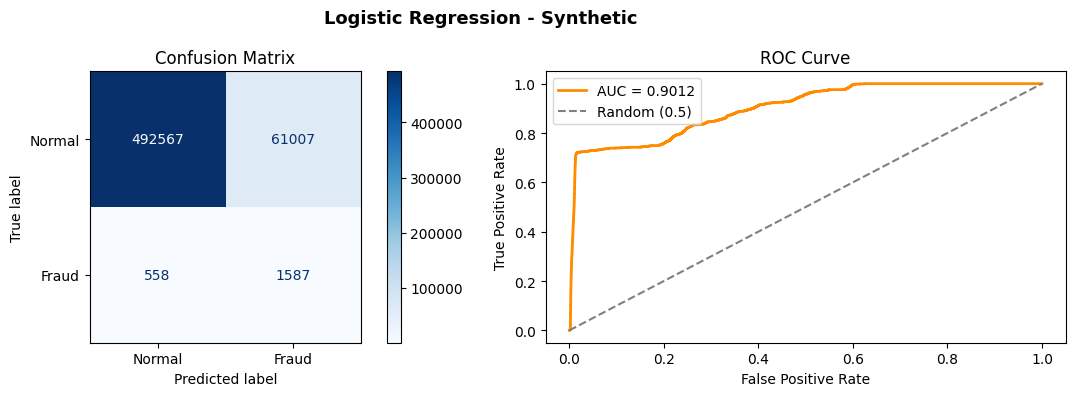


Random Forest | Synthetic
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    553574
       Fraud       0.74      0.50      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.75      0.80    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9501


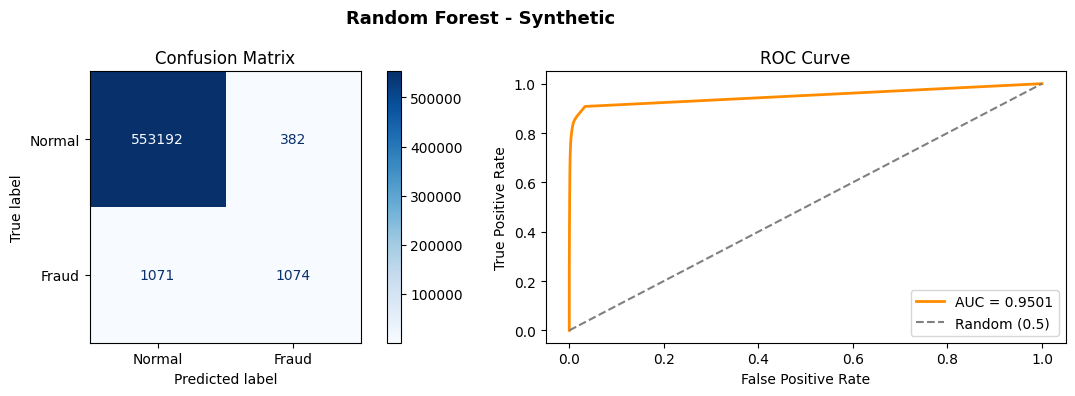


XGBoost | Synthetic
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    553574
       Fraud       0.13      0.86      0.22      2145

    accuracy                           0.98    555719
   macro avg       0.56      0.92      0.60    555719
weighted avg       1.00      0.98      0.99    555719

ROC-AUC: 0.9899


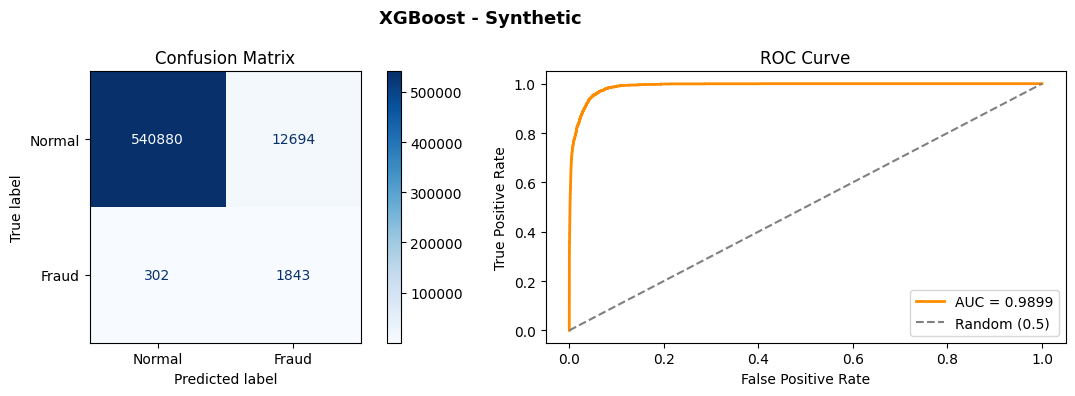

In [15]:
results = {}

# Logistic Regression
lr_s = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr_s, auc_lr_s = evaluate_model(
    lr_s, X_train_s, X_test_s, y_train_s, y_test_s,
    'Logistic Regression', 'Synthetic'
)
results['LR_Synthetic'] = {'model': model_lr_s, 'auc': auc_lr_s}

# Random Forest
rf_s = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf_s, auc_rf_s = evaluate_model(
    rf_s, X_train_s, X_test_s, y_train_s, y_test_s,
    'Random Forest', 'Synthetic'
)
results['RF_Synthetic'] = {'model': model_rf_s, 'auc': auc_rf_s}

# XGBoost - scale_pos_weight handles class imbalance similarly to class_weight='balanced'
xgb_s = XGBClassifier(
    scale_pos_weight=fraud_ratio_s,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model_xgb_s, auc_xgb_s = evaluate_model(
    xgb_s, X_train_s, X_test_s, y_train_s, y_test_s,
    'XGBoost', 'Synthetic'
)
results['XGB_Synthetic'] = {'model': model_xgb_s, 'auc': auc_xgb_s}

## 7. Training on Real Data

creditcard.csv split 80/20 into train and test.


Logistic Regression | Real
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9714


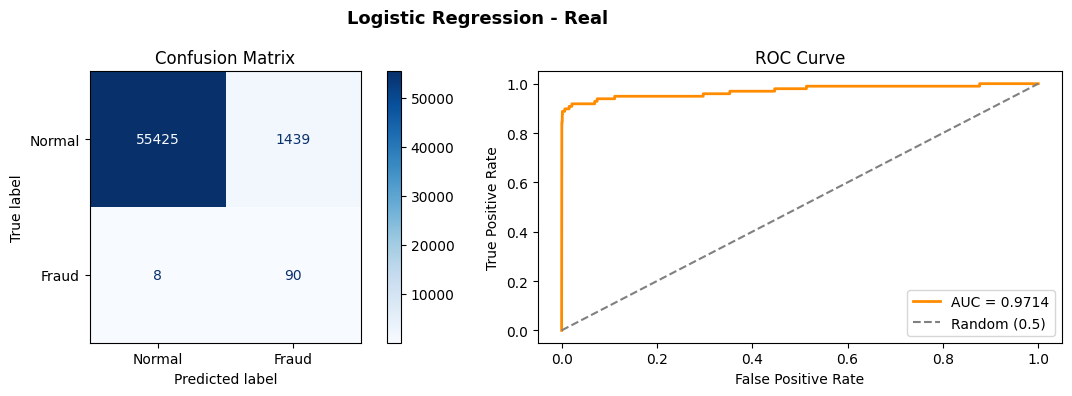


Random Forest | Real
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9580


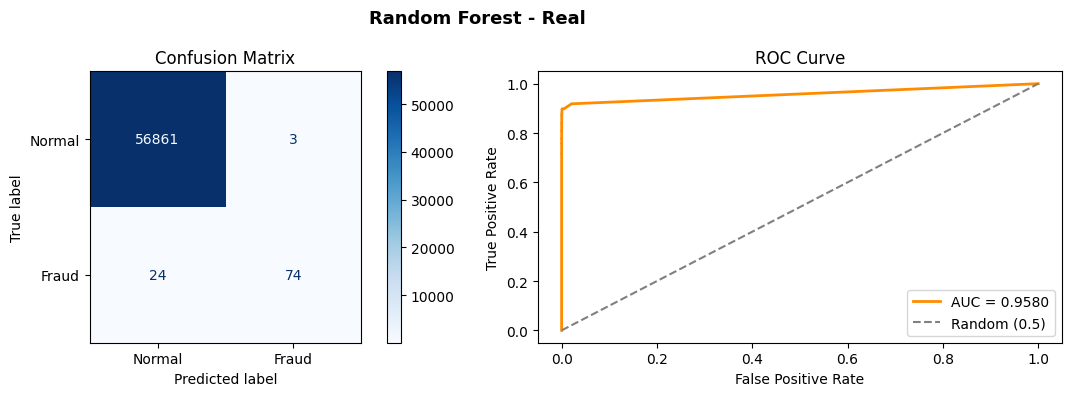


XGBoost | Real
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9670


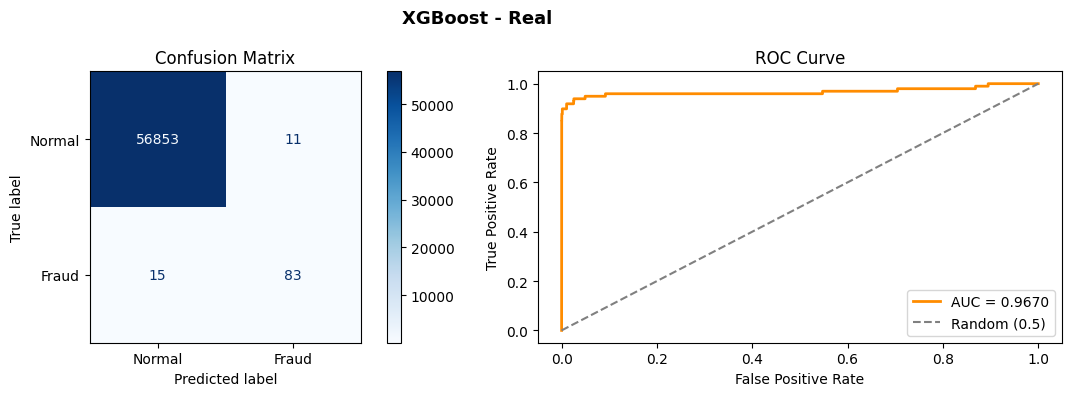

In [16]:
# Logistic Regression
lr_r = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr_r, auc_lr_r = evaluate_model(
    lr_r, X_train_r, X_test_r, y_train_r, y_test_r,
    'Logistic Regression', 'Real'
)
results['LR_Real'] = {'model': model_lr_r, 'auc': auc_lr_r}

# Random Forest
rf_r = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf_r, auc_rf_r = evaluate_model(
    rf_r, X_train_r, X_test_r, y_train_r, y_test_r,
    'Random Forest', 'Real'
)
results['RF_Real'] = {'model': model_rf_r, 'auc': auc_rf_r}

# XGBoost
xgb_r = XGBClassifier(
    scale_pos_weight=fraud_ratio_r,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model_xgb_r, auc_xgb_r = evaluate_model(
    xgb_r, X_train_r, X_test_r, y_train_r, y_test_r,
    'XGBoost', 'Real'
)
results['XGB_Real'] = {'model': model_xgb_r, 'auc': auc_xgb_r}

## 8. Model Comparison

All results side by side, sorted by ROC-AUC.

Model comparison:
Model   Dataset  ROC-AUC
  XGB Synthetic   0.9899
   LR      Real   0.9714
  XGB      Real   0.9670
   RF      Real   0.9580
   RF Synthetic   0.9501
   LR Synthetic   0.9012

Best model: XGB on Synthetic data (AUC = 0.9899)


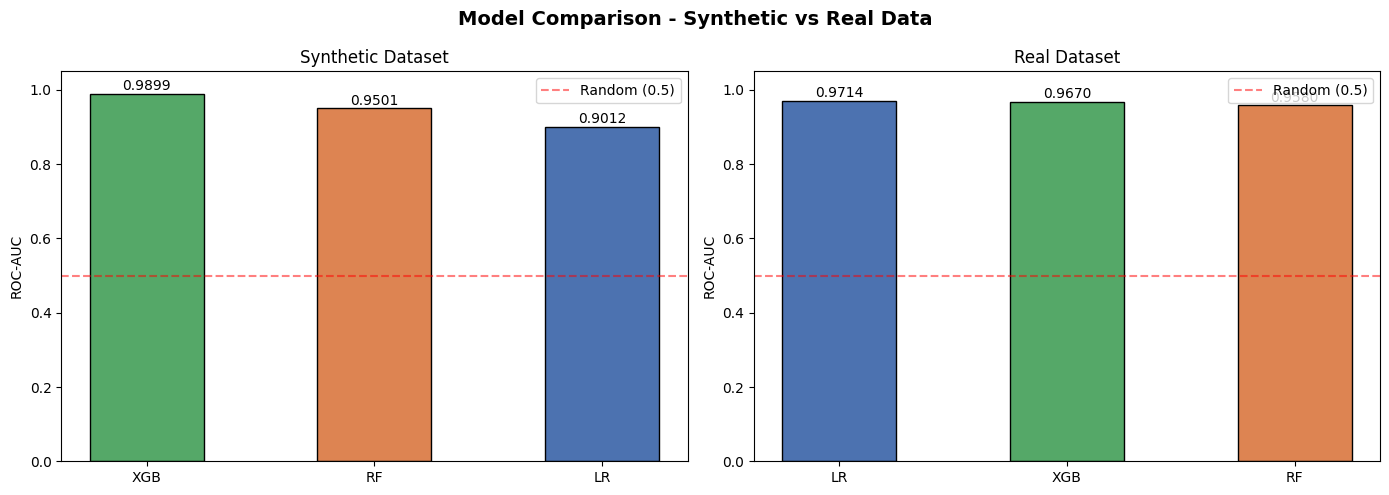

In [17]:
summary = pd.DataFrame([
    {
        'Model':   k.split('_')[0],
        'Dataset': k.split('_')[1],
        'ROC-AUC': round(v['auc'], 4)
    }
    for k, v in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('Model comparison:')
print(summary.to_string(index=False))
print(f"\nBest model: {summary.iloc[0]['Model']} on {summary.iloc[0]['Dataset']} data (AUC = {summary.iloc[0]['ROC-AUC']})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison - Synthetic vs Real Data', fontsize=14, fontweight='bold')

colors = {'LR': '#4C72B0', 'RF': '#DD8452', 'XGB': '#55A868'}

for ax, dataset in zip(axes, ['Synthetic', 'Real']):
    subset = summary[summary['Dataset'] == dataset]
    bars = ax.bar(
        subset['Model'],
        subset['ROC-AUC'],
        color=[colors.get(m, '#999') for m in subset['Model']],
        width=0.5,
        edgecolor='black'
    )
    for bar, val in zip(bars, subset['ROC-AUC']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{dataset} Dataset', fontsize=12)
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Save Models

We save the best model for each dataset and both scalers.
The scalers are required to preprocess new data consistently in the dashboard.

In [18]:
os.makedirs('../model', exist_ok=True)

best_synthetic_key = summary[summary['Dataset'] == 'Synthetic'].iloc[0]['Model']
best_real_key      = summary[summary['Dataset'] == 'Real'].iloc[0]['Model']

best_model_synthetic = results[f'{best_synthetic_key}_Synthetic']['model']
best_model_real      = results[f'{best_real_key}_Real']['model']

joblib.dump(best_model_synthetic, '../model/best_model_synthetic.pkl')
joblib.dump(best_model_real,      '../model/best_model_real.pkl')

# Scalers are saved separately - needed to preprocess new input data the same way
joblib.dump(scaler_s, '../model/scaler_synthetic.pkl')
joblib.dump(scaler_r, '../model/scaler_real.pkl')

print('Models saved to ../model/')
print(f'  best_model_synthetic.pkl  ({best_synthetic_key})')
print(f'  best_model_real.pkl       ({best_real_key})')
print('  scaler_synthetic.pkl')
print('  scaler_real.pkl')

Models saved to ../model/
  best_model_synthetic.pkl  (XGB)
  best_model_real.pkl       (LR)
  scaler_synthetic.pkl
  scaler_real.pkl
